In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
from matplotlib import font_manager
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

font_path = font_manager.findfont("DejaVu Sans")
print("FONT PATH:", font_path)

font_prop = font_manager.FontProperties(fname=font_path)


FONT PATH: /usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf


In [3]:
import pandas as pd
import os
from glob import glob
DATA_DIR = "/content/drive/MyDrive/GEE S2_Data/Traning"
csv_files = glob( os.path.join(DATA_DIR, "S1_*_TRAINING_data.csv") )
print(f"Tìm thấy {len(csv_files)} file CSV:")

for f in csv_files:
    print(f" - {f}")

df_list = [pd.read_csv(f) for f in csv_files]
df = pd.concat(df_list, ignore_index=True)
print(f"\n Thông tin DataFrame tổng hợp:")
print(f"   - Số dòng: {df.shape[0]:,}")
print(f"   - Số cột: {df.shape[1]}")
print(f"   - Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

display(df.head())


Tìm thấy 4 file CSV:
 - /content/drive/MyDrive/GEE S2_Data/Traning/S1_237_TRAINING_data.csv
 - /content/drive/MyDrive/GEE S2_Data/Traning/S1_49_TRAINING_data.csv
 - /content/drive/MyDrive/GEE S2_Data/Traning/S1_9_TRAINING_data.csv
 - /content/drive/MyDrive/GEE S2_Data/Traning/S1_274_TRAINING_data.csv

 Thông tin DataFrame tổng hợp:
   - Số dòng: 9,540,000
   - Số cột: 33
   - Memory usage: 3386.17 MB


,X_Coord,Y_Coord,B01,B02,B03,B04,B05,B06,B07,B08,...,B12_B03_Ratio,LABEL,Image_ID,Tile_ID,Tile_Cloud_Coverage,Tile_Nan_Percentage,Tile_Cloud_Pixels,Tile_Clear_Pixels,Sample_Type,Sample_ID
0,590605.0,2356795.0,0.2362,0.3740,0.3704,0.3560,0.3866,0.4419,0.4518,0.4596,...,0.869330,1,S2_237_TRAINING.tif,3,0.036069,0.072903,8766,234267,cloud,0
1,594335.0,2340825.0,0.1608,0.1382,0.1590,0.1506,0.2082,0.2927,0.3128,0.3078,...,0.916981,1,S2_237_TRAINING.tif,21,0.501998,0.246891,99106,98317,cloud,1
2,593425.0,2354635.0,0.0570,0.0768,0.1166,0.1026,0.1824,0.2649,0.2849,0.2884,...,1.030875,0,S2_237_TRAINING.tif,8,0.175684,0.077789,42472,199280,clear_sampled,2
3,573255.0,2306535.0,0.2149,0.2028,0.1926,0.1776,0.2032,0.2223,0.2263,0.2200,...,0.772586,1,S2_237_TRAINING.tif,56,0.698166,0.000000,183020,79124,cloud,3
4,577155.0,2333985.0,0.3425,0.3356,0.3344,0.3094,0.3435,0.3510,0.3525,0.3432,...,0.807416,1,S2_237_TRAINING.tif,37,0.550278,0.000000,144252,117892,cloud,4


PHÂN TÍCH PHÂN BỐ NHÃN VÀ CÂN BẰNG DỮ LIỆU
   - Label 0 (KHÔNG MÂY):
       Số lượng: 3,540,000 mẫu
       Tỷ lệ: 37.11%
   - Label 1 (MÂY):
       Số lượng: 6,000,000 mẫu
       Tỷ lệ: 62.89%

 TỶ LỆ MẤT CÂN BẰNG: 1.69:1


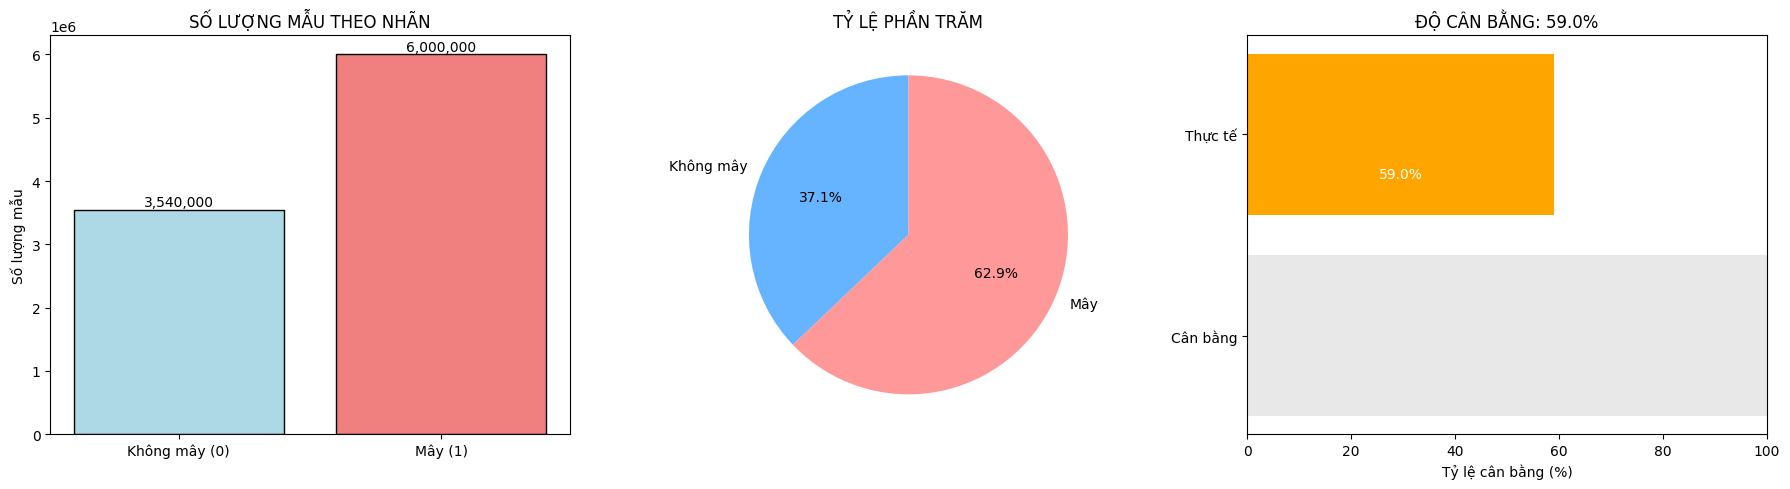


ĐÁNH GIÁ CÂN BẰNG DỮ LIỆU:
   DỮ LIỆU CÂN BẰNG TỐT


In [4]:
print("PHÂN TÍCH PHÂN BỐ NHÃN VÀ CÂN BẰNG DỮ LIỆU")

label_counts = df['LABEL'].value_counts().sort_index()
label_percent = label_counts / len(df) * 100

for label, count in label_counts.items():
    print(f"   - Label {label} ({'MÂY' if label==1 else 'KHÔNG MÂY'}):")
    print(f"       Số lượng: {count:,} mẫu")
    print(f"       Tỷ lệ: {label_percent[label]:.2f}%")

imbalance_ratio = label_counts.max() / label_counts.min()
print(f"\n TỶ LỆ MẤT CÂN BẰNG: {imbalance_ratio:.2f}:1")


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].bar(
    ['Không mây (0)', 'Mây (1)'],
    label_counts.values,
    color=['lightblue', 'lightcoral'],
    edgecolor='black'
)
axes[0].set_title(
    'SỐ LƯỢNG MẪU THEO NHÃN',
    fontproperties=font_prop,
    fontsize=12,
    fontweight='bold'
)
axes[0].set_ylabel(
    'Số lượng mẫu',
    fontproperties=font_prop
)

for i, v in enumerate(label_counts.values):
    axes[0].text(
        i,
        v + max(label_counts.values)*0.01,
        f'{v:,}',
        ha='center',
        fontweight='bold',
        fontproperties=font_prop
    )

colors = ['#66b3ff', '#ff9999']
axes[1].pie(
    label_counts.values,
    labels=['Không mây', 'Mây'],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontproperties': font_prop}
)
axes[1].set_title(
    'TỶ LỆ PHẦN TRĂM',
    fontproperties=font_prop,
    fontsize=12,
    fontweight='bold'
)

balance_score = min(label_counts.values) / max(label_counts.values) * 100

axes[2].barh(['Cân bằng'], [100], color='lightgray', alpha=0.5)
axes[2].barh(['Thực tế'], [balance_score], color='orange')

axes[2].set_xlim(0, 100)
axes[2].set_title(
    f'ĐỘ CÂN BẰNG: {balance_score:.1f}%',
    fontproperties=font_prop,
    fontsize=12,
    fontweight='bold'
)
axes[2].set_xlabel(
    'Tỷ lệ cân bằng (%)',
    fontproperties=font_prop
)

axes[2].text(
    balance_score / 2,
    0.8,
    f'{balance_score:.1f}%',
    ha='center',
    va='center',
    fontweight='bold',
    color='white',
    fontproperties=font_prop
)

plt.tight_layout()
plt.show()


print("\nĐÁNH GIÁ CÂN BẰNG DỮ LIỆU:")
if imbalance_ratio < 2:
    print("   DỮ LIỆU CÂN BẰNG TỐT")
elif imbalance_ratio < 5:
    print("   DỮ LIỆU HƠI MẤT CÂN BẰNG")
else:
    print("   DỮ LIỆU MẤT CÂN BẰNG NGHIÊM TRỌNG")


PHÂN TÍCH THEO TILE VÀ IMAGE
📊 THỐNG KÊ THEO TILE:
   - Tổng số tiles: 106
   - Mẫu trung bình/tile: 90000 ± 42724
   - Tile có nhiều mẫu nhất: 177,153 mẫu
   - Tile có ít mẫu nhất: 10,000 mẫu

📁 THỐNG KÊ THEO IMAGE:
   - S2_49_TRAINING.tif:
       Số tiles: 106.0
       Tổng mẫu: 2,560,000.0
       Tỷ lệ mây: 58.59%
   - S2_274_TRAINING.tif:
       Số tiles: 97.0
       Tổng mẫu: 2,470,000.0
       Tỷ lệ mây: 60.73%
   - S2_9_TRAINING.tif:
       Số tiles: 95.0
       Tổng mẫu: 2,450,000.0
       Tỷ lệ mây: 61.22%
   - S2_237_TRAINING.tif:
       Số tiles: 56.0
       Tổng mẫu: 2,060,000.0
       Tỷ lệ mây: 72.82%


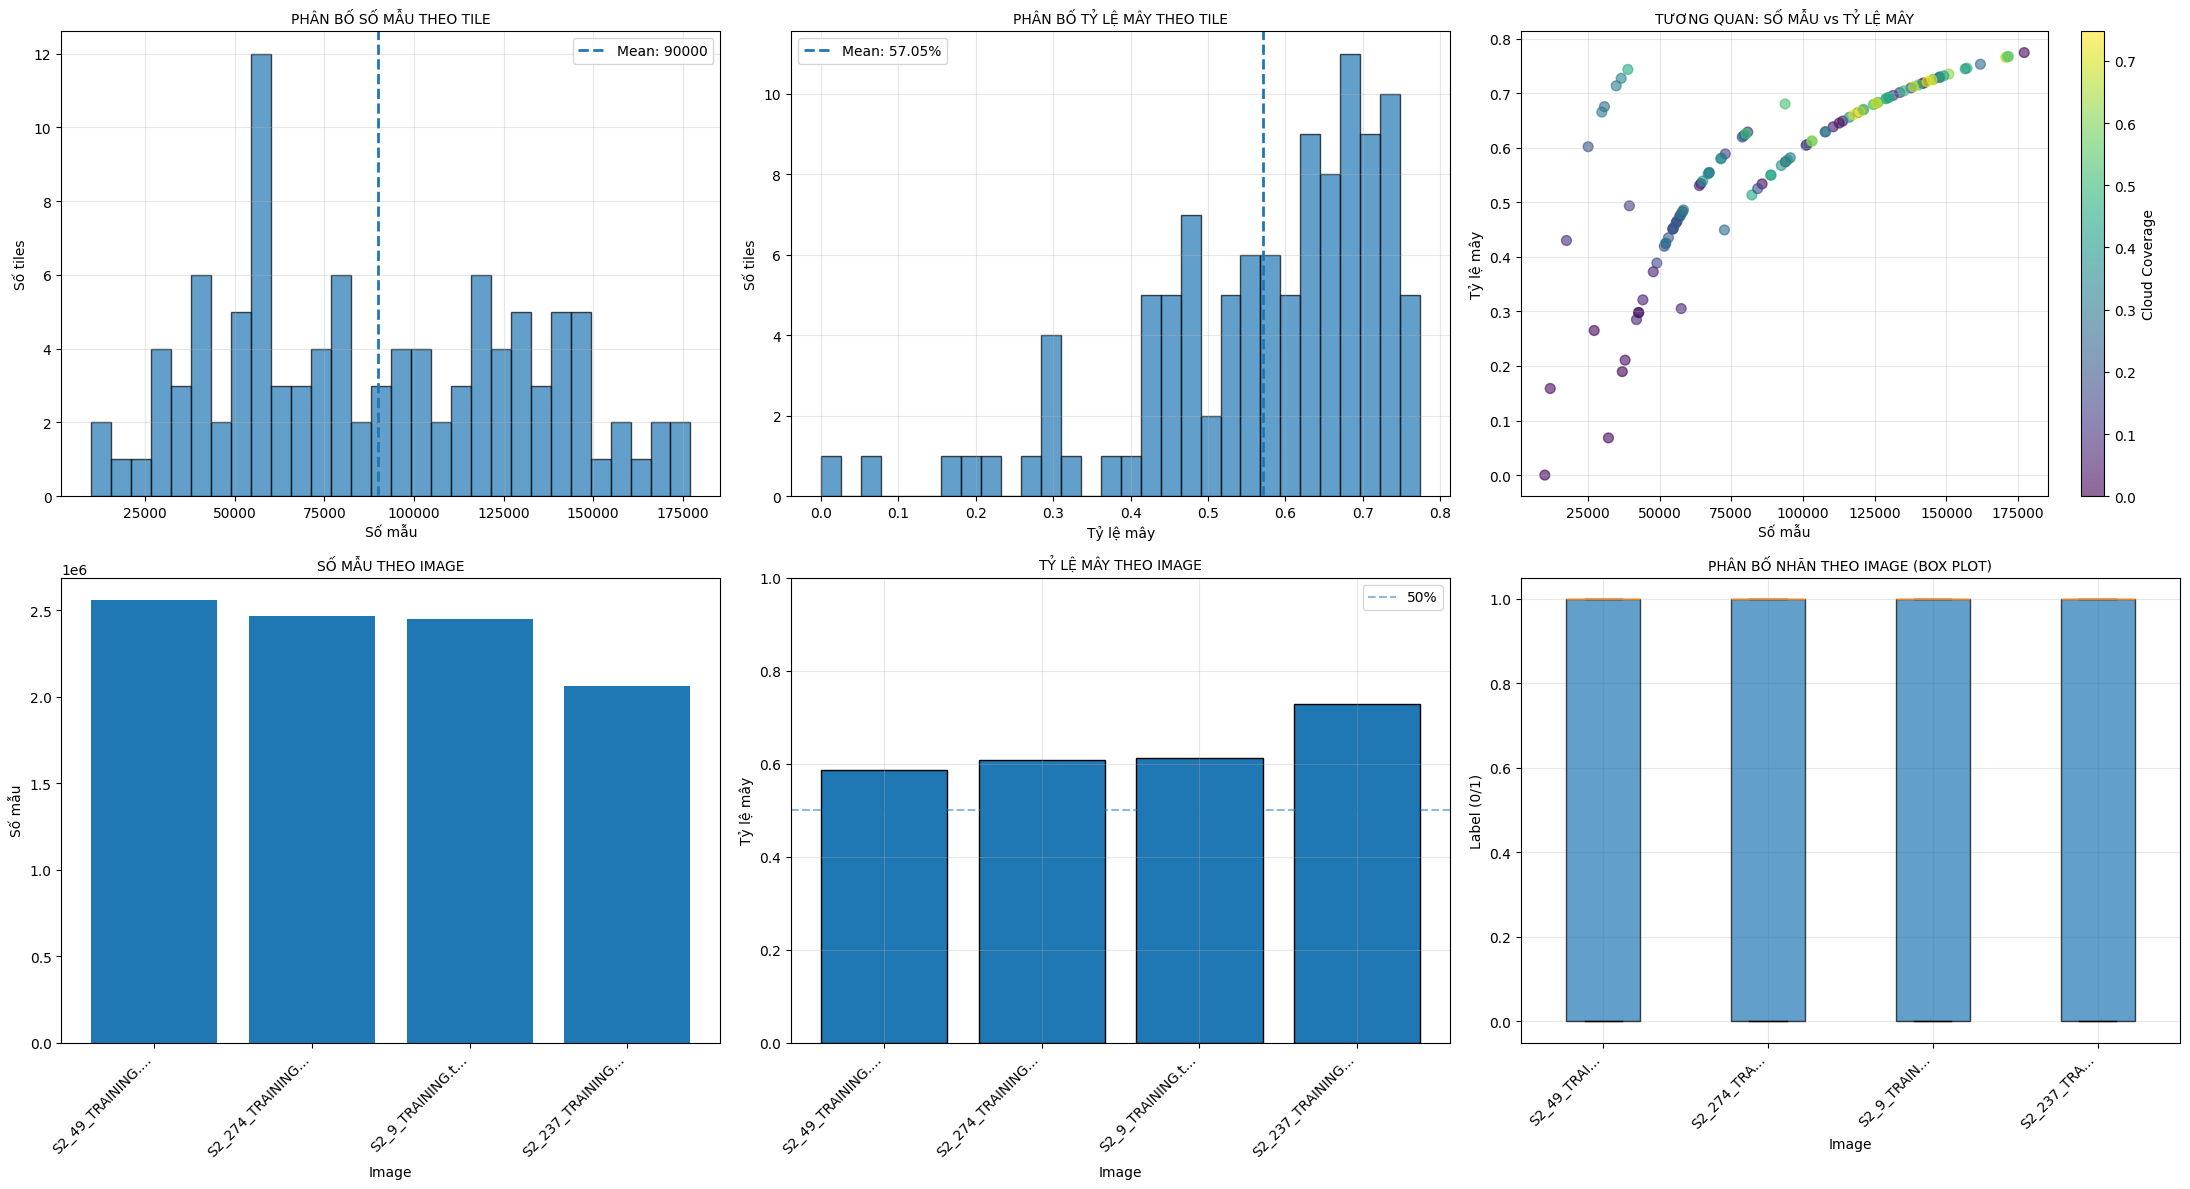


🏆 TOP 5 TILES CÓ NHIỀU MẪU NHẤT:


,Số_mẫu,Tỷ_lệ_mây,Cloud_Coverage
Tile_ID,,,
6,177153,0.7742,0.0126
37,171680,0.7670,0.5503
23,171286,0.7665,0.6017
16,170720,0.7657,0.6619
51,161875,0.7529,0.2548


In [5]:
# ================= PHÂN TÍCH THEO TILE VÀ IMAGE =================
print("PHÂN TÍCH THEO TILE VÀ IMAGE")

# ===== Thống kê theo Tile =====
tile_stats = df.groupby('Tile_ID').agg(
    Số_mẫu=('LABEL', 'count'),
    Tỷ_lệ_mây=('LABEL', 'mean'),
    Std_mây=('LABEL', 'std'),
    Cloud_Coverage=('Tile_Cloud_Coverage', 'first'),
    Image_ID=('Image_ID', 'first')
).round(4)

print(f"THỐNG KÊ THEO TILE:")
print(f"   - Tổng số tiles: {tile_stats.shape[0]}")
print(f"   - Mẫu trung bình/tile: {tile_stats['Số_mẫu'].mean():.0f} ± {tile_stats['Số_mẫu'].std():.0f}")
print(f"   - Tile có nhiều mẫu nhất: {tile_stats['Số_mẫu'].max():,} mẫu")
print(f"   - Tile có ít mẫu nhất: {tile_stats['Số_mẫu'].min():,} mẫu")

# ===== Thống kê theo Image =====
image_stats = df.groupby('Image_ID').agg(
    Số_tiles=('Tile_ID', 'nunique'),
    Tổng_mẫu=('LABEL', 'count'),
    Tỷ_lệ_mây=('LABEL', 'mean')
).sort_values('Tổng_mẫu', ascending=False).round(4)

print(f"\nTHỐNG KÊ THEO IMAGE:")
for image, row in image_stats.iterrows():
    print(f"   - {image}:")
    print(f"       Số tiles: {row['Số_tiles']}")
    print(f"       Tổng mẫu: {row['Tổng_mẫu']:,}")
    print(f"       Tỷ lệ mây: {row['Tỷ_lệ_mây']:.2%}")

# ================= VISUALIZATION =================
fig, axes = plt.subplots(2, 3, figsize=(22, 12))

# 1. Phân bố số mẫu theo tile
axes[0,0].hist(tile_stats['Số_mẫu'], bins=30, edgecolor='black', alpha=0.7)
axes[0,0].axvline(tile_stats['Số_mẫu'].mean(), linestyle='--', linewidth=2,
                  label=f'Mean: {tile_stats["Số_mẫu"].mean():.0f}')
axes[0,0].set_title('PHÂN BỐ SỐ MẪU THEO TILE', fontweight='bold', fontproperties=font_prop)
axes[0,0].set_xlabel('Số mẫu', fontproperties=font_prop)
axes[0,0].set_ylabel('Số tiles', fontproperties=font_prop)
axes[0,0].legend(prop=font_prop)
axes[0,0].grid(True, alpha=0.3)

# 2. Phân bố tỷ lệ mây theo tile
axes[0,1].hist(tile_stats['Tỷ_lệ_mây'], bins=30, edgecolor='black', alpha=0.7)
axes[0,1].axvline(tile_stats['Tỷ_lệ_mây'].mean(), linestyle='--', linewidth=2,
                  label=f'Mean: {tile_stats["Tỷ_lệ_mây"].mean():.2%}')
axes[0,1].set_title('PHÂN BỐ TỶ LỆ MÂY THEO TILE', fontweight='bold', fontproperties=font_prop)
axes[0,1].set_xlabel('Tỷ lệ mây', fontproperties=font_prop)
axes[0,1].set_ylabel('Số tiles', fontproperties=font_prop)
axes[0,1].legend(prop=font_prop)
axes[0,1].grid(True, alpha=0.3)

# 3. Tương quan số mẫu và tỷ lệ mây
scatter = axes[0,2].scatter(
    tile_stats['Số_mẫu'],
    tile_stats['Tỷ_lệ_mây'],
    alpha=0.6,
    c=tile_stats['Cloud_Coverage'],
    cmap='viridis',
    s=50
)
axes[0,2].set_title('TƯƠNG QUAN: SỐ MẪU vs TỶ LỆ MÂY', fontweight='bold', fontproperties=font_prop)
axes[0,2].set_xlabel('Số mẫu', fontproperties=font_prop)
axes[0,2].set_ylabel('Tỷ lệ mây', fontproperties=font_prop)
cbar = plt.colorbar(scatter, ax=axes[0,2])
cbar.set_label('Cloud Coverage', fontproperties=font_prop)
axes[0,2].grid(True, alpha=0.3)

# 4. Số mẫu theo image
image_names = [name[:15] + '...' if len(name) > 15 else name for name in image_stats.index]
axes[1,0].bar(range(len(image_stats)), image_stats['Tổng_mẫu'])
axes[1,0].set_title('SỐ MẪU THEO IMAGE', fontweight='bold', fontproperties=font_prop)
axes[1,0].set_xlabel('Image', fontproperties=font_prop)
axes[1,0].set_ylabel('Số mẫu', fontproperties=font_prop)
axes[1,0].set_xticks(range(len(image_stats)))
axes[1,0].set_xticklabels(image_names, rotation=45, ha='right', fontproperties=font_prop)

# 5. Tỷ lệ mây theo image
axes[1,1].bar(range(len(image_stats)), image_stats['Tỷ_lệ_mây'], edgecolor='black')
axes[1,1].axhline(0.5, linestyle='--', alpha=0.5, label='50%')
axes[1,1].set_title('TỶ LỆ MÂY THEO IMAGE', fontweight='bold', fontproperties=font_prop)
axes[1,1].set_xlabel('Image', fontproperties=font_prop)
axes[1,1].set_ylabel('Tỷ lệ mây', fontproperties=font_prop)
axes[1,1].set_xticks(range(len(image_stats)))
axes[1,1].set_xticklabels(image_names, rotation=45, ha='right', fontproperties=font_prop)
axes[1,1].set_ylim(0, 1)
axes[1,1].legend(prop=font_prop)
axes[1,1].grid(True, alpha=0.3)

# 6. Box plot nhãn theo image
data_to_plot = [df[df['Image_ID'] == img]['LABEL'].values for img in image_stats.index]
labels = [img[:10] + '...' if len(img) > 10 else img for img in image_stats.index]
bp = axes[1,2].boxplot(data_to_plot, labels=labels, patch_artist=True)
for patch in bp['boxes']:
    patch.set_alpha(0.7)

axes[1,2].set_title('PHÂN BỐ NHÃN THEO IMAGE (BOX PLOT)', fontweight='bold', fontproperties=font_prop)
axes[1,2].set_xlabel('Image', fontproperties=font_prop)
axes[1,2].set_ylabel('Label (0/1)', fontproperties=font_prop)
axes[1,2].set_xticklabels(labels, rotation=45, ha='right', fontproperties=font_prop)
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ===== Top 5 tiles có nhiều mẫu nhất =====
print("\n🏆 TOP 5 TILES CÓ NHIỀU MẪU NHẤT:")
display(tile_stats.nlargest(5, 'Số_mẫu')[['Số_mẫu', 'Tỷ_lệ_mây', 'Cloud_Coverage']])


🌈 PHÂN TÍCH SPECTRAL BANDS - ĐẶC TRƯNG PHỔ
📡 CÓ 11 SPECTRAL BANDS:
   - B01    - B02    - B03    - B04    - B05    - B06    - B07    - B08    - B09    - B11    - B12 

 THỐNG KÊ SPECTRAL BANDS:


,Min,Max,Mean,Std,Median
B01,0.0000,2.2884,0.254074,0.234407,0.1781
B02,0.0001,2.3384,0.248028,0.228972,0.1692
B03,0.0014,2.1432,0.246319,0.209770,0.1732
B04,0.0001,2.0200,0.234983,0.205109,0.1638
B05,0.0055,2.0937,0.270921,0.209078,0.1982
B06,0.0000,1.9416,0.310555,0.187514,0.2544
B07,0.0000,1.8746,0.327469,0.182513,0.2782
B08,0.0001,1.8824,0.318693,0.180174,0.2724
B09,0.0000,1.9052,0.432906,0.292213,0.3312
B11,0.0007,1.5344,0.275137,0.168178,0.2323


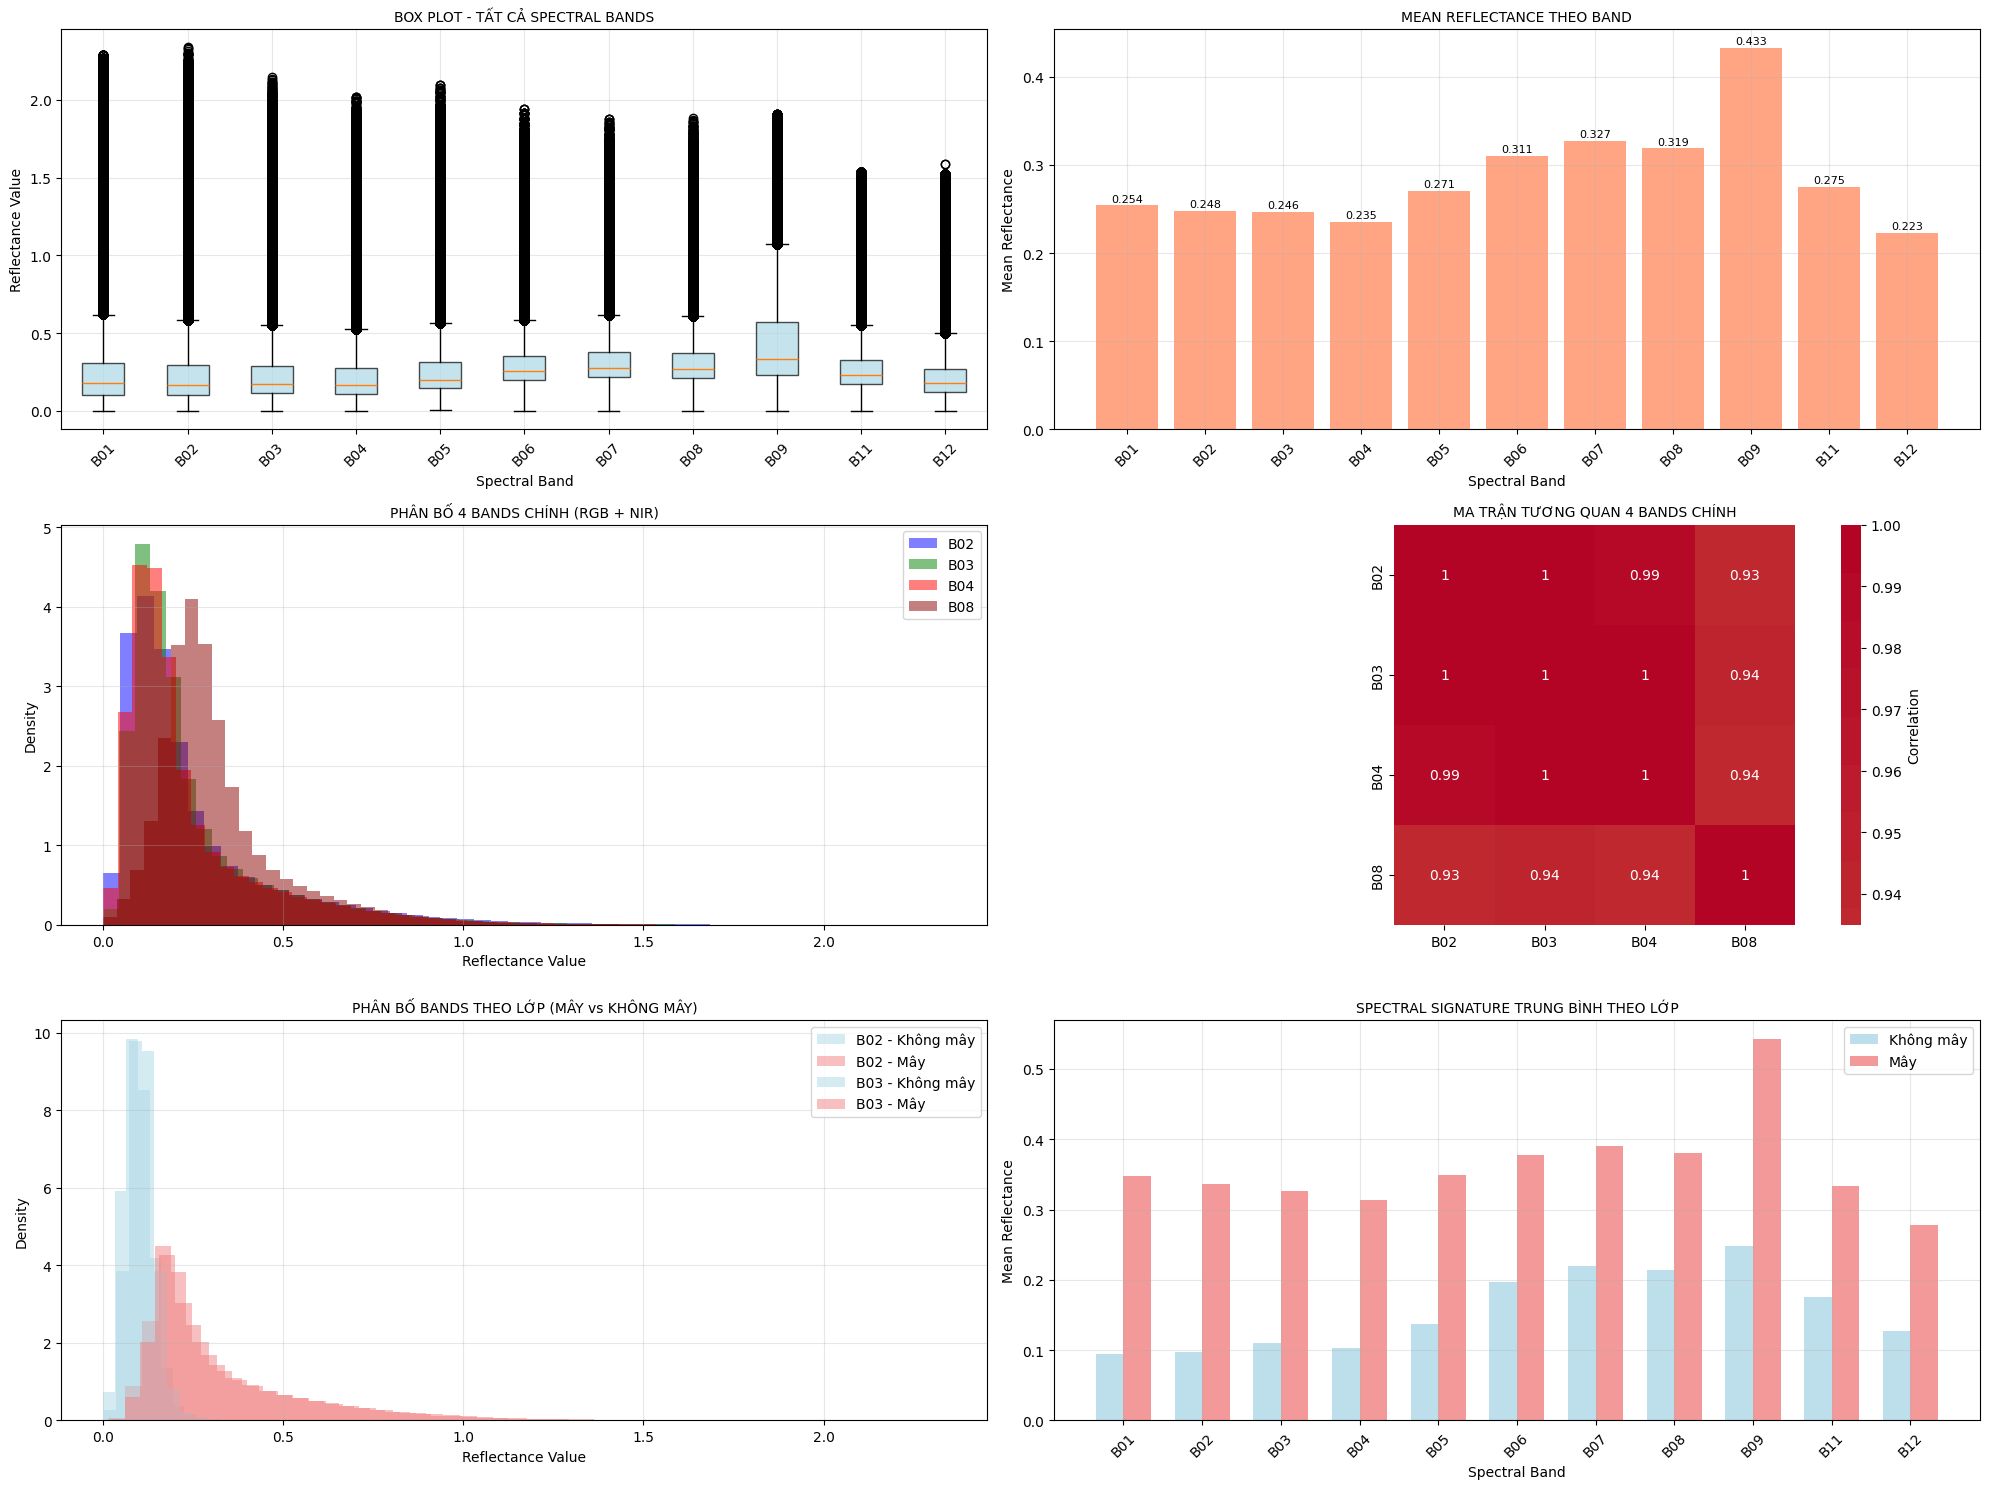


📈 PHÂN TÍCH KHÁC BIỆT SPECTRAL SIGNATURE:
   - B02: Mây=0.3366, Không mây=0.0979, Diff=0.2387 (+243.8%)
   - B03: Mây=0.3265, Không mây=0.1104, Diff=0.2162 (+195.8%)
   - B04: Mây=0.3130, Không mây=0.1028, Diff=0.2102 (+204.6%)
   - B08: Mây=0.3800, Không mây=0.2147, Diff=0.1653 (+77.0%)


In [6]:
print("PHÂN TÍCH SPECTRAL BANDS - ĐẶC TRƯNG PHỔ")

band_columns = [col for col in df.columns if col.startswith('B') and col[1:].isdigit()]
band_columns = sorted(band_columns, key=lambda x: int(x[1:]))

print(f" CÓ {len(band_columns)} SPECTRAL BANDS:")
for band in band_columns:
    print(f"   - {band}", end=" ")
print()

band_stats = pd.DataFrame()
for band in band_columns:
    band_stats.loc[band, 'Min'] = df[band].min()
    band_stats.loc[band, 'Max'] = df[band].max()
    band_stats.loc[band, 'Mean'] = df[band].mean()
    band_stats.loc[band, 'Std'] = df[band].std()
    band_stats.loc[band, 'Median'] = df[band].median()

print("\n THỐNG KÊ SPECTRAL BANDS:")
display(band_stats)

# Visualization bands
fig, axes = plt.subplots(3, 2, figsize=(20, 15))

# 1. Box plot tất cả bands
data_to_plot = [df[band].dropna().values for band in band_columns]
bp1 = axes[0,0].boxplot(data_to_plot, labels=band_columns, patch_artist=True)
for patch in bp1['boxes']:
    patch.set_facecolor('lightblue')
    patch.set_alpha(0.7)

axes[0,0].set_title('BOX PLOT - TẤT CẢ SPECTRAL BANDS', fontsize=12, fontweight='bold', fontproperties=font_prop)
axes[0,0].set_xlabel('Spectral Band', fontproperties=font_prop)
axes[0,0].set_ylabel('Reflectance Value', fontproperties=font_prop)
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].grid(True, alpha=0.3)

# 2. Mean reflectance của từng band
axes[0,1].bar(band_columns, band_stats['Mean'], color='coral', alpha=0.7)
axes[0,1].set_title('MEAN REFLECTANCE THEO BAND', fontsize=12, fontweight='bold', fontproperties=font_prop)
axes[0,1].set_xlabel('Spectral Band', fontproperties=font_prop)
axes[0,1].set_ylabel('Mean Reflectance', fontproperties=font_prop)
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].grid(True, alpha=0.3)

# Thêm giá trị trên bar
for i, v in enumerate(band_stats['Mean']):
    axes[0,1].text(i, v + band_stats['Mean'].max()*0.01, f'{v:.3f}',
                  ha='center', fontsize=8, fontproperties=font_prop)

# 3. Phân bố 4 bands chính (RGB + NIR)
main_bands = ['B02', 'B03', 'B04', 'B08']  # Blue, Green, Red, NIR
colors = ['blue', 'green', 'red', 'darkred']

for idx, (band, color) in enumerate(zip(main_bands, colors)):
    axes[1,0].hist(df[band].dropna(), bins=50, alpha=0.5,
                  color=color, label=band, density=True)
axes[1,0].set_title('PHÂN BỐ 4 BANDS CHÍNH (RGB + NIR)', fontsize=12, fontweight='bold', fontproperties=font_prop)
axes[1,0].set_xlabel('Reflectance Value', fontproperties=font_prop)
axes[1,0].set_ylabel('Density', fontproperties=font_prop)
axes[1,0].legend(prop=font_prop)
axes[1,0].grid(True, alpha=0.3)

# 4. Tương quan giữa các bands chính
import seaborn as sns
corr_matrix = df[main_bands].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, ax=axes[1,1], cbar_kws={'label': 'Correlation'},
            annot_kws={'fontproperties': font_prop})
axes[1,1].set_title('MA TRẬN TƯƠNG QUAN 4 BANDS CHÍNH', fontsize=12, fontweight='bold', fontproperties=font_prop)

# 5. Phân bố bands theo lớp (mây vs không mây)
for band in main_bands[:2]:  # 2 bands đầu
    axes[2,0].hist(df[df['LABEL'] == 0][band].dropna(), bins=50, alpha=0.5,
                  color='lightblue', label=f'{band} - Không mây', density=True)
    axes[2,0].hist(df[df['LABEL'] == 1][band].dropna(), bins=50, alpha=0.5,
                  color='lightcoral', label=f'{band} - Mây', density=True)
axes[2,0].set_title('PHÂN BỐ BANDS THEO LỚP (MÂY vs KHÔNG MÂY)', fontsize=12, fontweight='bold', fontproperties=font_prop)
axes[2,0].set_xlabel('Reflectance Value', fontproperties=font_prop)
axes[2,0].set_ylabel('Density', fontproperties=font_prop)
axes[2,0].legend(prop=font_prop)
axes[2,0].grid(True, alpha=0.3)

# 6. Spectral signature trung bình theo lớp
cloud_mean = df[df['LABEL'] == 1][band_columns].mean()
clear_mean = df[df['LABEL'] == 0][band_columns].mean()

x_pos = np.arange(len(band_columns))
width = 0.35
axes[2,1].bar(x_pos - width/2, clear_mean.values, width,
             label='Không mây', color='lightblue', alpha=0.8)
axes[2,1].bar(x_pos + width/2, cloud_mean.values, width,
             label='Mây', color='lightcoral', alpha=0.8)
axes[2,1].set_title('SPECTRAL SIGNATURE TRUNG BÌNH THEO LỚP', fontsize=12, fontweight='bold', fontproperties=font_prop)
axes[2,1].set_xlabel('Spectral Band', fontproperties=font_prop)
axes[2,1].set_ylabel('Mean Reflectance', fontproperties=font_prop)
axes[2,1].set_xticks(x_pos)
axes[2,1].set_xticklabels(band_columns, rotation=45, fontproperties=font_prop)
axes[2,1].legend(prop=font_prop)
axes[2,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Phân tích spectral signature difference
print("\n PHÂN TÍCH KHÁC BIỆT SPECTRAL SIGNATURE:")
for band in main_bands:
    cloud_mean_val = df[df['LABEL'] == 1][band].mean()
    clear_mean_val = df[df['LABEL'] == 0][band].mean()
    diff = cloud_mean_val - clear_mean_val
    diff_pct = diff / clear_mean_val * 100 if clear_mean_val != 0 else 0
    print(f"   - {band}: Mây={cloud_mean_val:.4f}, Không mây={clear_mean_val:.4f}, "
          f"Diff={diff:.4f} ({diff_pct:+.1f}%)")


📐 PHÂN TÍCH SPECTRAL INDICES - CHỈ SỐ PHỔ
📐 CÓ 10 SPECTRAL INDICES:
   - NDVI
   - NDSI
   - NDWI
   - NDMI
   - B11_B08_Ratio
   - B02_B04_Ratio
   - B8A_B11_Ratio
   - B01_B11_Ratio
   - B05_B04_Ratio
   - B12_B03_Ratio

📊 THỐNG KÊ SPECTRAL INDICES:


,Min,Max,Mean,Std,Median
NDVI,-0.992188,0.995546,0.210457,0.194585,0.171266
NDSI,-0.927405,0.981506,-0.094978,0.205811,-0.081560
NDWI,-0.932773,0.994652,-0.181464,0.182603,-0.153374
NDMI,-0.977273,0.978395,0.091435,0.128658,0.077780
B11_B08_Ratio,0.010920,87.000000,0.857869,0.223723,0.855667
B02_B04_Ratio,0.015873,183.000015,1.033662,0.170972,1.040923
B8A_B11_Ratio,0.000000,77.428574,1.310560,0.386876,1.221925
B01_B11_Ratio,0.000000,65.142860,0.919523,0.539880,0.858816
B05_B04_Ratio,0.271695,91.000008,1.262037,0.279817,1.189836
B12_B03_Ratio,0.000000,24.997591,1.020549,0.445426,0.936295


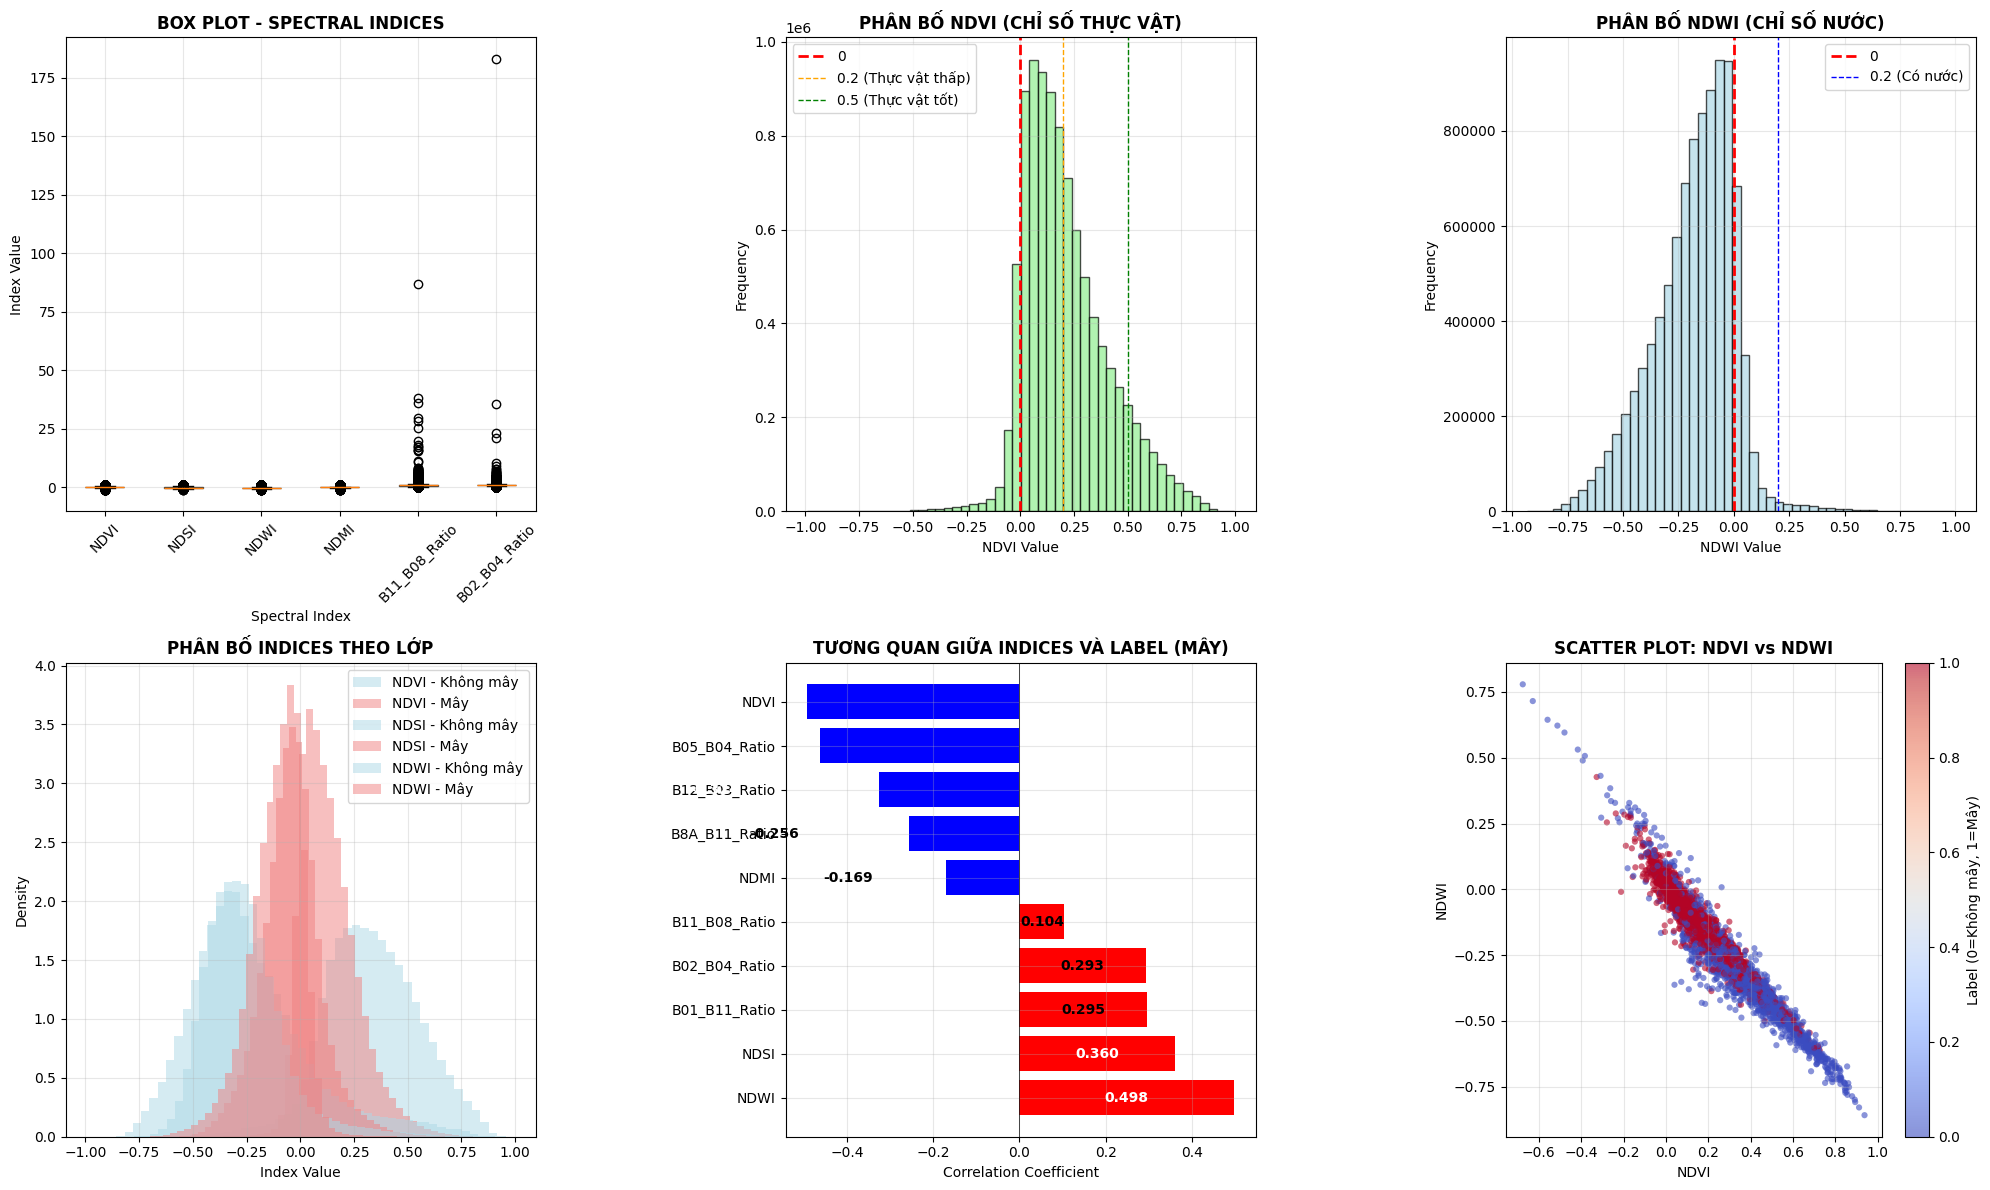


📊 GIÁ TRỊ TRUNG BÌNH INDICES THEO LỚP:


,Không mây,Mây,Chênh lệch,Chênh lệch %
NDVI,0.3352,0.1369,-0.1983,-59.1595
NDSI,-0.1913,-0.0381,0.1532,-80.0607
NDWI,-0.2998,-0.1116,0.1882,-62.7657
NDMI,0.1198,0.0747,-0.0451,-37.6456
B11_B08_Ratio,0.8275,0.8758,0.0483,5.8342
B02_B04_Ratio,0.9684,1.0721,0.1037,10.7067


In [7]:
# Cell 6: PHÂN TÍCH SPECTRAL INDICES (CHỈ SỐ PHỔ)
print("="*70)
print("📐 PHÂN TÍCH SPECTRAL INDICES - CHỈ SỐ PHỔ")
print("="*70)

# Các spectral indices
indices_columns = ['NDVI', 'NDSI', 'NDWI', 'NDMI',
                   'B11_B08_Ratio', 'B02_B04_Ratio',
                   'B8A_B11_Ratio', 'B01_B11_Ratio',
                   'B05_B04_Ratio', 'B12_B03_Ratio']

# Chỉ lấy indices có trong dataset
indices_columns = [idx for idx in indices_columns if idx in df.columns]

print(f"📐 CÓ {len(indices_columns)} SPECTRAL INDICES:")
for idx in indices_columns:
    print(f"   - {idx}")

# Thống kê indices
indices_stats = pd.DataFrame()
for idx in indices_columns:
    indices_stats.loc[idx, 'Min'] = df[idx].min()
    indices_stats.loc[idx, 'Max'] = df[idx].max()
    indices_stats.loc[idx, 'Mean'] = df[idx].mean()
    indices_stats.loc[idx, 'Std'] = df[idx].std()
    indices_stats.loc[idx, 'Median'] = df[idx].median()

print("\n📊 THỐNG KÊ SPECTRAL INDICES:")
display(indices_stats)

# Visualization indices
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Chọn 6 indices quan trọng nhất
important_indices = indices_columns[:6] if len(indices_columns) >= 6 else indices_columns

# 1. Box plot các indices
data_to_plot = [df[idx].dropna().values for idx in important_indices]
bp = axes[0,0].boxplot(data_to_plot, labels=important_indices, patch_artist=True)
colors = plt.cm.Set3(np.arange(len(important_indices)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[0,0].set_title('BOX PLOT - SPECTRAL INDICES', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Spectral Index')
axes[0,0].set_ylabel('Index Value')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].grid(True, alpha=0.3)

# 2. Phân bố NDVI (chỉ số thực vật quan trọng)
if 'NDVI' in df.columns:
    axes[0,1].hist(df['NDVI'], bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
    axes[0,1].axvline(0, color='red', linestyle='--', linewidth=2, label='0')
    axes[0,1].axvline(0.2, color='orange', linestyle='--', linewidth=1, label='0.2 (Thực vật thấp)')
    axes[0,1].axvline(0.5, color='green', linestyle='--', linewidth=1, label='0.5 (Thực vật tốt)')
    axes[0,1].set_title('PHÂN BỐ NDVI (CHỈ SỐ THỰC VẬT)', fontsize=12, fontweight='bold')
    axes[0,1].set_xlabel('NDVI Value')
    axes[0,1].set_ylabel('Frequency')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)

# 3. Phân bố NDWI (chỉ số nước)
if 'NDWI' in df.columns:
    axes[0,2].hist(df['NDWI'], bins=50, color='lightblue', edgecolor='black', alpha=0.7)
    axes[0,2].axvline(0, color='red', linestyle='--', linewidth=2, label='0')
    axes[0,2].axvline(0.2, color='blue', linestyle='--', linewidth=1, label='0.2 (Có nước)')
    axes[0,2].set_title('PHÂN BỐ NDWI (CHỈ SỐ NƯỚC)', fontsize=12, fontweight='bold')
    axes[0,2].set_xlabel('NDWI Value')
    axes[0,2].set_ylabel('Frequency')
    axes[0,2].legend()
    axes[0,2].grid(True, alpha=0.3)

# 4. Phân bố indices theo lớp (mây vs không mây)
for idx_idx, idx in enumerate(important_indices[:3]):  # 3 indices đầu
    axes[1,0].hist(df[df['LABEL'] == 0][idx].dropna(), bins=50, alpha=0.5,
                  color='lightblue', label=f'{idx} - Không mây', density=True)
    axes[1,0].hist(df[df['LABEL'] == 1][idx].dropna(), bins=50, alpha=0.5,
                  color='lightcoral', label=f'{idx} - Mây', density=True)
axes[1,0].set_title('PHÂN BỐ INDICES THEO LỚP', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Index Value')
axes[1,0].set_ylabel('Density')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# 5. Tương quan giữa các indices và label
correlations = df[indices_columns + ['LABEL']].corr()['LABEL'].drop('LABEL').sort_values(ascending=False)

bars = axes[1,1].barh(range(len(correlations)), correlations.values,
                     color=['red' if x > 0 else 'blue' for x in correlations.values])
axes[1,1].set_title('TƯƠNG QUAN GIỮA INDICES VÀ LABEL (MÂY)', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Correlation Coefficient')
axes[1,1].set_yticks(range(len(correlations)))
axes[1,1].set_yticklabels(correlations.index)
axes[1,1].axvline(0, color='black', linewidth=0.5)
axes[1,1].grid(True, alpha=0.3)

# Thêm giá trị correlation
for i, (bar, corr) in enumerate(zip(bars, correlations.values)):
    axes[1,1].text(corr/2 if corr > 0 else corr*2, i, f'{corr:.3f}',
                  va='center', ha='center' if corr > 0 else 'right',
                  color='white' if abs(corr) > 0.3 else 'black', fontweight='bold')

# 6. Scatter plot NDVI vs NDWI với màu theo label
if 'NDVI' in df.columns and 'NDWI' in df.columns:
    sample_df = df.sample(min(5000, len(df)))  # Lấy mẫu để tránh quá tải
    scatter = axes[1,2].scatter(sample_df['NDVI'], sample_df['NDWI'],
                               c=sample_df['LABEL'], cmap='coolwarm',
                               alpha=0.6, s=20, edgecolors='none')
    axes[1,2].set_title('SCATTER PLOT: NDVI vs NDWI', fontsize=12, fontweight='bold')
    axes[1,2].set_xlabel('NDVI')
    axes[1,2].set_ylabel('NDWI')
    axes[1,2].grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=axes[1,2], label='Label (0=Không mây, 1=Mây)')

plt.tight_layout()
plt.show()

# Phân tích indices theo lớp
print("\n📊 GIÁ TRỊ TRUNG BÌNH INDICES THEO LỚP:")
indices_comparison = pd.DataFrame()
for idx in important_indices:
    indices_comparison.loc[idx, 'Không mây'] = df[df['LABEL'] == 0][idx].mean()
    indices_comparison.loc[idx, 'Mây'] = df[df['LABEL'] == 1][idx].mean()
    indices_comparison.loc[idx, 'Chênh lệch'] = indices_comparison.loc[idx, 'Mây'] - indices_comparison.loc[idx, 'Không mây']
    indices_comparison.loc[idx, 'Chênh lệch %'] = (indices_comparison.loc[idx, 'Chênh lệch'] /
                                                   indices_comparison.loc[idx, 'Không mây'] * 100)

display(indices_comparison.round(4))

🔗 MA TRẬN TƯƠNG QUAN TOÀN DIỆN
📊 TÍNH TƯƠNG QUAN CHO 12 FEATURES QUAN TRỌNG


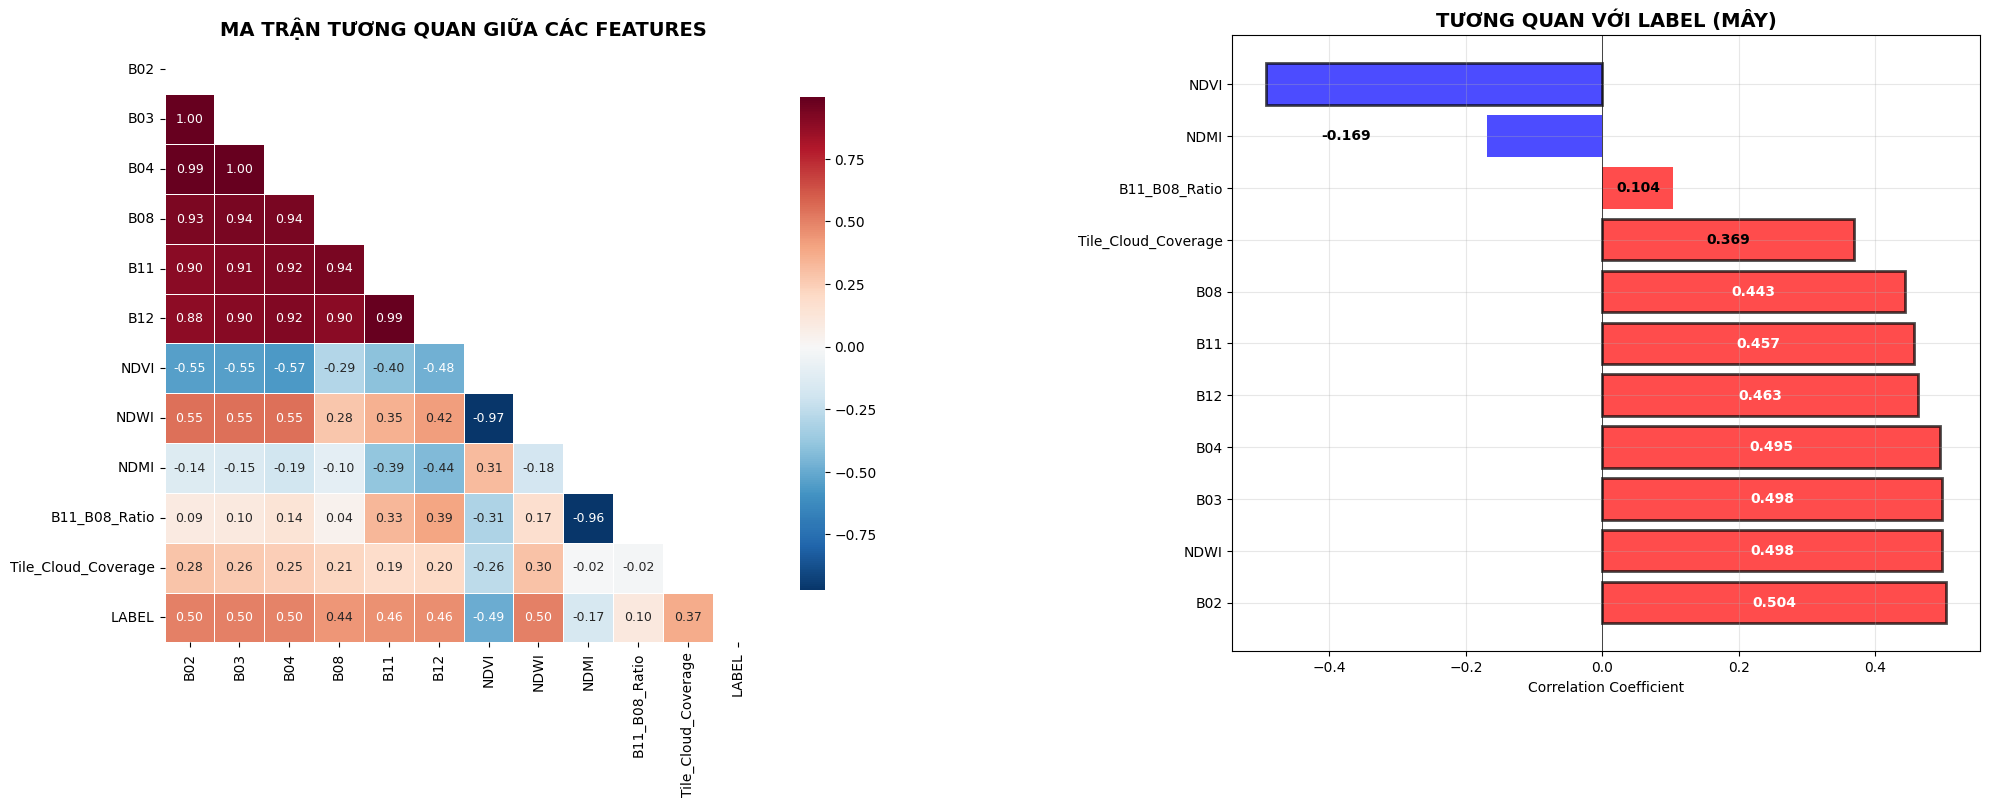


📈 PHÂN TÍCH TƯƠNG QUAN VỚI LABEL (MÂY):

🔴 CÁC FEATURES TƯƠNG QUAN DƯƠNG MẠNH (LIÊN QUAN ĐẾN MÂY):
   - B02: 0.504 ⭐⭐⭐⭐⭐
   - NDWI: 0.498 ⭐⭐⭐⭐
   - B03: 0.498 ⭐⭐⭐⭐
   - B04: 0.495 ⭐⭐⭐⭐
   - B12: 0.463 ⭐⭐⭐⭐
   - B11: 0.457 ⭐⭐⭐⭐
   - B08: 0.443 ⭐⭐⭐⭐
   - Tile_Cloud_Coverage: 0.369 ⭐⭐⭐

🔵 CÁC FEATURES TƯƠNG QUAN ÂM MẠNH (LIÊN QUAN ĐẾN KHÔNG MÂY):
   - NDVI: -0.492 ⭐⭐⭐⭐

⚪ CÁC FEATURES ÍT TƯƠNG QUAN (|r| < 0.1):


In [8]:
# Cell 7: MA TRẬN TƯƠNG QUAN TOÀN DIỆN
print(" MA TRẬN TƯƠNG QUAN TOÀN DIỆN")

# Chọn các features quan trọng
important_features = ['B02', 'B03', 'B04', 'B08', 'B11', 'B12',
                      'NDVI', 'NDWI', 'NDMI', 'B11_B08_Ratio',
                      'Tile_Cloud_Coverage', 'LABEL']

# Chỉ lấy features có trong dataset
available_features = [f for f in important_features if f in df.columns]

print(f"TÍNH TƯƠNG QUAN CHO {len(available_features)} FEATURES QUAN TRỌNG")

# Tính correlation matrix
corr_matrix = df[available_features].corr()

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# 1. Heatmap correlation matrix
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .8},
            annot=True, fmt='.2f', annot_kws={'size': 9}, ax=axes[0])
axes[0].set_title('MA TRẬN TƯƠNG QUAN GIỮA CÁC FEATURES', fontsize=14, fontweight='bold')

# 2. Correlation với label
label_corr = corr_matrix['LABEL'].sort_values(ascending=False)
label_corr = label_corr.drop('LABEL')

colors = ['red' if x > 0 else 'blue' for x in label_corr.values]
bars = axes[1].barh(range(len(label_corr)), label_corr.values, color=colors, alpha=0.7)
axes[1].set_title('TƯƠNG QUAN VỚI LABEL (MÂY)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Correlation Coefficient')
axes[1].set_yticks(range(len(label_corr)))
axes[1].set_yticklabels(label_corr.index)
axes[1].axvline(0, color='black', linewidth=0.5)
axes[1].grid(True, alpha=0.3)

# Thêm giá trị và đánh dấu features quan trọng
for i, (bar, corr, feature) in enumerate(zip(bars, label_corr.values, label_corr.index)):
    # Màu và độ dày cho features quan trọng
    if abs(corr) > 0.3:
        bar.set_edgecolor('black')
        bar.set_linewidth(2)

    # Hiển thị giá trị
    text_color = 'white' if abs(corr) > 0.4 else 'black'
    text_x = corr/2 if corr > 0 else corr*2
    text_ha = 'center' if corr > 0 else 'right'
    axes[1].text(text_x, i, f'{corr:.3f}', va='center', ha=text_ha,
                color=text_color, fontweight='bold')

plt.tight_layout()
plt.show()

# Phân tích chi tiết correlation với label
print("\n PHÂN TÍCH TƯƠNG QUAN VỚI LABEL (MÂY):")

print("\n CÁC FEATURES TƯƠNG QUAN DƯƠNG MẠNH (LIÊN QUAN ĐẾN MÂY):")
positive_corr = label_corr[label_corr > 0.3]
if len(positive_corr) > 0:
    for feature, corr in positive_corr.items():
        print(f"   - {feature}: {corr:.3f} {'⭐' * int(corr*10)}")
else:
    print("   Không có features nào tương quan dương mạnh")

print("\n CÁC FEATURES TƯƠNG QUAN ÂM MẠNH (LIÊN QUAN ĐẾN KHÔNG MÂY):")
negative_corr = label_corr[label_corr < -0.3]
if len(negative_corr) > 0:
    for feature, corr in negative_corr.items():
        print(f"   - {feature}: {corr:.3f} {'' * int(abs(corr)*10)}")
else:
    print("   Không có features nào tương quan âm mạnh")

print("\n CÁC FEATURES ÍT TƯƠNG QUAN (|r| < 0.1):")